# PA2 — Regret Minimization in Repeated Normal-Form Games
*Intelligent Agents — Programming Assignment 2*

**Tasks**
1. Compute **average strategy** and **external regret** for the row player from a history of play.
2. Implement **Follow-the-Leader (FTL)** against an input column action sequence, and a **self-play** version (both players run FTL).
3. Implement **Multiplicative Weights Update (MWU)** against an input column action sequence, and a **self-play** version.
4. Plot the **distance to a given NE** for the two **self-play** versions on a specified game.

**What to submit:** your completed `.ipynb` on Canvas. Before submitting, do **Runtime → Restart and run all**.

**Conventions**
- Games are two-player normal-form with row payoff matrix `A` (shape `(n_row, n_col)`) and column payoff matrix `B` (same shape).
- Action indices are **0-based**.
- Use only `numpy` and `matplotlib` (no seaborn).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def show(arr, name=None):
    if name:
        print(name, "=", end=" ")
    print(np.array(arr))

### 🧩 Task 1 — Average Strategy & External Regret (row player)

Implement:

- `average_strategy_row(row_actions, n_actions)` → empirical distribution over the row player's actions.
  - Input: list/array of row action indices in `{0,…,n_actions-1}`
  - Output: 1D `np.ndarray` of length `n_actions` summing to 1
  - Edge case: if empty, return the **uniform** distribution.

- `external_regret_row(row_actions, col_actions, A)` → nonnegative float:
$$
R_T \,=\, \max_{a}\sum_{t=1}^T A[a, j_t] - \sum_{t=1}^T A[i_t, j_t].
$$
- Edge case: if empty, return `0.0`.

In [2]:
def average_strategy_row(row_actions, n_actions):
    """Return the empirical distribution over row actions.
    If no actions, return uniform.
    """
    if type(row_actions) is list:
        row_actions = np.array(row_actions, dtype=int)
    if row_actions.size == 0: return np.ones(n_actions)/n_actions
    return np.bincount(row_actions, minlength=n_actions) / len(row_actions)


def external_regret_row(row_actions, col_actions, A):
    """External regret of the row player vs the best fixed row action.
    Regret(T) = max_a sum_t A[a, j_t] - sum_t A[i_t, j_t].
    """
    if not row_actions: return 0.0
    assert len(row_actions) == len(col_actions)
    actual = sum(A[i, j] for i, j in zip(row_actions, col_actions))
    best_fixed = max(sum(A[a, j] for j in col_actions) for a in range(A.shape[0]))
    return best_fixed - actual

In [3]:
# === Public tests: Task 1 ===
def _ok(name, fn):
    try:
        fn(); print(f"✅ {name} — passed")
    except AssertionError as e:
        print(f"❌ {name} — {e}")

def test_avg_empty_uniform():
    n=3
    avg = average_strategy_row([], n)
    assert avg.shape==(n,)
    assert np.allclose(avg.sum(),1.0)
    assert np.allclose(avg, np.ones(n)/n)

def test_avg_counts():
    avg = average_strategy_row([0,2,2,1,2], 3)
    assert np.allclose(avg, [1/5,1/5,3/5])
    avg = average_strategy_row([1,0,0,1,0], 3) # no action 2
    assert np.allclose(avg, [3/5,2/5,0])

def test_regret_matching_pennies():
    A = np.array([[+1,-1],[-1,+1]], float)
    row = [0,0,0,0]
    col = [1,1,0,1]
    reg = external_regret_row(row, col, A)
    assert np.isclose(reg, 4.0)

_ok("T1: avg empty uniform", test_avg_empty_uniform)
_ok("T1: avg simple counts", test_avg_counts)
_ok("T1: regret (MP)", test_regret_matching_pennies)

✅ T1: avg empty uniform — passed
✅ T1: avg simple counts — passed
✅ T1: regret (MP) — passed


### 🧩 Task 2 — Follow-the-Leader (FTL): opponent-given and self-play

- `expected_payoff_row_against_mix(A, q)` → expected payoffs for each row action vs a column mixed strategy `q`.
- `ftl_row(col_actions, A, tie_break='first', seed=None)` → row action sequence of length `T` (no peeking at `col_actions[t]` when choosing round `t`).
- `ftl_self_play(A, B, T, tie_break='first', seed=None)` → simulate both players running FTL **simultaneously** for `T` rounds.
  - Returns `(row_actions, col_actions)`.

In [4]:
def expected_payoff_row_against_mix(A, q):
    """Return v[a] = sum_j A[a,j] * q[j] for each row action a."""
    return A @ q


def ftl_row(col_actions, A, tie_break='first', seed=None):
    """FTL for the row player against realized column actions (no peeking)."""
    if seed is not None:
        rng = np.random.default_rng(seed)
    n_rows = A.shape[0]
    row_actions = np.array([], dtype=int)
    if tie_break == 'first': row_actions = np.append(row_actions, 0)
    elif tie_break == 'random': row_actions = np.append(row_actions, rng.choice(n_rows))
    for j in range(1,len(col_actions)):
        pi = average_strategy_row(col_actions[:j], 2)
        ev = expected_payoff_row_against_mix(A, pi)
        if tie_break == 'first':
            row_actions = np.append(row_actions, np.argmax(ev))
        elif tie_break == 'random':
            max_ev = np.max(ev)
            candidates = np.flatnonzero(ev == max_ev)
            row_actions = np.append(row_actions, rng.choice(candidates))
        else:
            raise ValueError("tie_break must be 'first' or 'random'")
    return row_actions


def ftl_self_play(A, B, T, tie_break='first', seed=None):
    """Self-play: both players run FTL based on the opponent's prefix empirical distribution.
    Return (row_actions, col_actions)."""
    if seed is not None:
        rng = np.random.default_rng(seed)
    row_actions = np.array([], dtype=int)
    col_actions = np.array([], dtype=int)
    for i in range(T):
        if i == 0:
            if tie_break == 'first':
                row_actions = np.append(row_actions, 0)
                col_actions = np.append(col_actions, 0)
            elif tie_break == 'random':
                row_actions = np.append(row_actions, rng.choice(A.shape[0]))
                col_actions = np.append(col_actions, rng.choice(B.shape[0]))
            continue
        else:
            pi_col = average_strategy_row(col_actions, B.shape[0])
            ev_row = expected_payoff_row_against_mix(A, pi_col)
            if tie_break == 'first':
                row_actions = np.append(row_actions, np.argmax(ev_row))
            elif tie_break == 'random':
                max_ev_row = np.max(ev_row)
                candidates_row = np.flatnonzero(ev_row == max_ev_row)
                row_actions = np.append(row_actions, rng.choice(candidates_row))
            pi_row = average_strategy_row(row_actions[:-1], A.shape[0])
            ev_col = expected_payoff_row_against_mix(B.T, pi_row)
            if tie_break == 'first':
                col_actions = np.append(col_actions, np.argmax(ev_col))
            elif tie_break == 'random':
                max_ev_col = np.max(ev_col)
                candidates_col = np.flatnonzero(ev_col == max_ev_col)
                col_actions = np.append(col_actions, rng.choice(candidates_col))
    return (row_actions, col_actions)

In [5]:
# === Public tests: Task 2 ===
def _ok2(name, fn):
    try:
        fn(); print(f"✅ {name} — passed")
    except AssertionError as e:
        print(f"❌ {name} — {e}")

def test_expected_row_mix():
    A = np.array([[1,0],[0,1]], float)
    q = np.array([0.25,0.75])
    v = expected_payoff_row_against_mix(A, q)
    assert np.allclose(v, [0.25,0.75])

def test_ftl_row_basic():
    A = np.array([[1,0],[0,1]], float)
    col = [1,1,1,1,1]
    row = ftl_row(col, A, tie_break='first')
    assert row[0] == 0 and np.all(row[1:] == 1)

def test_ftl_row2():
    A = np.array([[1,0],[0,1]], float)
    col = [1,0,0,1,0]
    row = ftl_row(col, A, tie_break='first')
    assert np.all(row == [0,1,0,0,0])
    col = [1,1,0,0,0,0]
    row = ftl_row(col, A, tie_break='first')
    assert np.all(row == [0,1,1,1,0,0])

def test_ftl_self_play_shapes():
    A = np.array([[1,0],[0,1]], float); B = A.copy()
    T = 10
    r,c = ftl_self_play(A,B,T,tie_break='first',seed=42)
    print(r,'\n',c)
    assert r.shape==(T,) and c.shape==(T,)

def test_ftl_self_play_adversarial():
    A = np.array([[1,0],[0,1]], float); B = A.copy()*-1 + 1 # 0sum, A xor B scores
    T = 20
    r,c = ftl_self_play(A,B,T,tie_break='first',seed=42)
    print(r,'\n',c)
    assert r.shape==(T,) and c.shape==(T,) # watch that each player switches to score when their opponent's scoring action is chosen >50% of the time, choosing action 0 on ties

_ok2("T2: expected payoff vs mix", test_expected_row_mix)
_ok2("T2: ftl_row basic", test_ftl_row_basic)
_ok2("T2: ftl_row2", test_ftl_row2)
_ok2("T2: self-play shapes", test_ftl_self_play_shapes) # cooperative, both players benefit and reassure each other by choosing the same action
_ok2("T2: self-play", test_ftl_self_play_adversarial) # adversarial, players are forced to switch when their opponent chooses their scoring action >50% of the time

✅ T2: expected payoff vs mix — passed
✅ T2: ftl_row basic — passed
✅ T2: ftl_row2 — passed
[0 0 0 0 0 0 0 0 0 0] 
 [0 0 0 0 0 0 0 0 0 0]
✅ T2: self-play shapes — passed
[0 0 0 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0] 
 [0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 1 1 1 1 1]
✅ T2: self-play — passed


### 🧩 Task 3 — Multiplicative Weights Update (MWU): opponent-given and self-play

- `mwu_row(col_actions, A, eta, seed=None)` → `(row_actions, probs_over_time)` where `probs_over_time[t] = x_t` (distribution **before** sampling round `t`).
- `mwu_self_play(A, B, T, eta_row, eta_col, seed=None)` → simulate both players using MWU.
  - Returns `(row_actions, col_actions, probs_row_over_time, probs_col_over_time)`.

In [6]:
def mwu_row(col_actions, A, eta, seed=None):
    """MWU for the row player against realized column actions.
    Return (row_actions, probs_over_time)."""
    if seed is not None:
        rng = np.random.default_rng(seed)
    n_rows, n_cols = A.shape

    weights = np.ones(n_rows)
    probs_over_time = []
    row_actions = []

    for t, c in enumerate(col_actions):
        x_t = weights / weights.sum()
        probs_over_time.append(x_t.copy())
        r = rng.choice(n_rows, p=x_t)
        row_actions.append(r)

        losses = -A[:,c]
        weights *= np.exp(-eta*losses)
    return np.array(row_actions), np.array(probs_over_time)


def mwu_self_play(A, B, T, eta_row, eta_col, seed=None):
    """Self-play MWU for T rounds.
    Return (row_actions, col_actions, probs_row_over_time, probs_col_over_time)."""
    if seed is not None:
        rng = np.random.default_rng(seed)
    n_rows, n_cols = A.shape
    w_row = np.ones(n_rows)
    w_col = np.ones(n_cols)
    
    probs_row, probs_col = [], []
    row_actions, col_actions = [], []
    for t in range(T):
        x_t = w_row / w_row.sum()
        y_t = w_col / w_col.sum()
        probs_row.append(x_t.copy())
        probs_col.append(y_t.copy())

        r = rng.choice(n_rows, p=x_t)
        c = rng.choice(n_cols, p=y_t)
        row_actions.append(r)
        col_actions.append(c)
        
        loss_row = -A[:, c]
        loss_col = -B[r, :]
        w_row *= np.exp(-eta_row * loss_row)
        w_col *= np.exp(-eta_col * loss_col)
    
    return (np.array(row_actions),
            np.array(col_actions),
            np.array(probs_row),
            np.array(probs_col))

In [10]:
# === Public tests: Task 3 ===
def _ok3(name, fn):
    try:
        fn(); print(f"✅ {name} — passed")
    except AssertionError as e:
        print(f"❌ {name} — {e}")

def test_mwu_shapes():
    A = np.array([[1,0],[0,1]], float)
    col = [0,1,0,1]
    row, P = mwu_row(col, A, eta=0.2, seed=631)
    print(col)
    print(P)
    assert row.shape==(len(col),) and P.shape==(len(col), A.shape[0])
    assert np.allclose(P.sum(axis=1),1.0)

def test_mwu2():
    A = np.array([[1,0],[0,1]], float)
    col = [0,0,0,0,1,1,0,1]
    row, P = mwu_row(col, A, eta=0.2, seed=42)
    print(col)
    # print(row)
    print(P)
    assert row.shape==(len(col),) and P.shape==(len(col), A.shape[0])
    assert np.allclose(P.sum(axis=1),1.0)

def test_mwu_self_play_shapes():
    A = np.array([[1,0],[0,1]], float); B = A.copy()
    T=25
    r,c,Pr,Pc = mwu_self_play(A,B,T,eta_row=0.4,eta_col=0.2,seed=42)
    print(r,'\n',c)
    print(Pr,'\n',Pc)
    assert r.shape==(T,) and c.shape==(T,)
    assert Pr.shape==(T,A.shape[0]) and Pc.shape==(T,B.shape[1])

def test_mwu_self_play_adversary():
    A = np.array([[1,0],[0,1]], float); B = A.copy()*-1 + 1 # 0sum, A xor B scores
    T=25
    r,c,Pr,Pc = mwu_self_play(A,B,T,eta_row=0.4,eta_col=0.2,seed=42)
    print(r,'\n',c)
    print(Pr,'\n',Pc)
    assert r.shape==(T,) and c.shape==(T,)
    assert Pr.shape==(T,A.shape[0]) and Pc.shape==(T,B.shape[1])

def test_mwu_self_play_adversary2():
    A = np.array([[1,0],[0,1]], float); B = A.copy()*-1 + 1 # 0sum, A xor B scores
    T=35
    r,c,Pr,Pc = mwu_self_play(A,B,T,eta_row=0.3,eta_col=0.3,seed=42)
    print(r,'\n',c)
    # print(Pr,'\n',Pc)
    assert r.shape==(T,) and c.shape==(T,)
    assert Pr.shape==(T,A.shape[0]) and Pc.shape==(T,B.shape[1])

_ok3("T3: mwu_row shapes", test_mwu_shapes)
_ok3("T3: mwu_row shapes", test_mwu2) # shift weight to a_0 and observe the weight shift back as a_1 is chosen
_ok3("T3: mwu_self_play shapes", test_mwu_self_play_shapes) # with larger T and eta_row we see convergence to a_0 where both players commonly benefit
_ok3("T3: mwu_self_play adversary", test_mwu_self_play_adversary) # Pr reacts faster than Pc and will shift weights of a_0 and a_1 by greater magnitude
_ok3("T3: mwu_self_play adversary 2", test_mwu_self_play_adversary2) # Pr(scores on same) and Pc(scores on different) have equal eta and both change their actions frequently

[0, 1, 0, 1]
[[0.5      0.5     ]
 [0.549834 0.450166]
 [0.5      0.5     ]
 [0.549834 0.450166]]
✅ T3: mwu_row shapes — passed
[0, 0, 0, 0, 1, 1, 0, 1]
[[0.5        0.5       ]
 [0.549834   0.450166  ]
 [0.59868766 0.40131234]
 [0.64565631 0.35434369]
 [0.68997448 0.31002552]
 [0.64565631 0.35434369]
 [0.59868766 0.40131234]
 [0.64565631 0.35434369]]
✅ T3: mwu_row shapes — passed
[1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1] 
 [0 1 1 1 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1]
[[0.5        0.5       ]
 [0.59868766 0.40131234]
 [0.5        0.5       ]
 [0.40131234 0.59868766]
 [0.31002552 0.68997448]
 [0.23147522 0.76852478]
 [0.16798161 0.83201839]
 [0.11920292 0.88079708]
 [0.16798161 0.83201839]
 [0.23147522 0.76852478]
 [0.16798161 0.83201839]
 [0.11920292 0.88079708]
 [0.0831727  0.9168273 ]
 [0.05732418 0.94267582]
 [0.0831727  0.9168273 ]
 [0.05732418 0.94267582]
 [0.03916572 0.96083428]
 [0.02659699 0.97340301]
 [0.01798621 0.98201379]
 [0.01212843 0.98787157]
 [0.008162

### 🧩 Task 4 — Distance to NE for Self-Play (FTL & MWU)

Given a game `(A,B)` and a target **row NE mix** `x_star`, plot the distance
$ d_t = \|\bar{x}_t - x^*\|_1 $ for the **self-play** FTL and MWU runs.

- `average_strategy_over_time_row(row_actions, n_actions)` → `(T, n_row)` cumulative averages.
- `distance_to_NE(avg_over_time, x_star, ord='l1')` → vector `d` of length `T`.
- `compare_selfplay_convergence(A, B, T, x_star, eta_row, eta_col, seed=None)`
  - Run `ftl_self_play` and `mwu_self_play` on the same game/horizon/seed.
  - Return `{'d_ftl': d_ftl, 'd_mwu': d_mwu}` and **plot** both curves.

In [8]:
def average_strategy_over_time_row(row_actions, n_actions):
    """Return cumulative average strategy over time as an array of shape (T, n_actions)."""
    T = len(row_actions)
    avg_strats = np.zeros((T, n_actions))
    counts = np.zeros(n_actions)

    for t, a in enumerate(row_actions, start=1):
        counts[a] += 1
        avg_strats[t-1] = counts / t  # normalize
    return avg_strats


def distance_to_NE(avg_over_time, x_star, ord='l1'):
    """Return d_t = || avg_over_time[t] - x_star ||_ord over t."""
    avg_over_time = np.asarray(avg_over_time)
    x_star = np.asarray(x_star)

    dists = np.linalg.norm(avg_over_time - x_star, ord=1 if ord=='l1' else 2, axis=1)
    return dists


def compare_selfplay_convergence(A, B, T, x_star, eta_row, eta_col, seed=None):
    """Run FTL and MWU self-play and compare distance-to-NE for the row player.
    Return {'d_ftl': d_ftl, 'd_mwu': d_mwu}. Also plot both curves."""
    # --- MWU self-play ---
    r_mwu, c_mwu, Pr, Pc = mwu_self_play(A, B, T, eta_row, eta_col, seed=seed)
    avg_mwu = average_strategy_over_time_row(r_mwu, A.shape[0])
    d_mwu = distance_to_NE(avg_mwu, x_star, ord='l1')
    
    # --- FTL self-play ---
    r_ftl, c_ftl = ftl_self_play(A, B, T, seed=seed)
    avg_ftl = average_strategy_over_time_row(r_ftl, A.shape[0])
    d_ftl = distance_to_NE(avg_ftl, x_star, ord='l1')
    
    # --- Plotting ---
    plt.figure(figsize=(7,5))
    plt.plot(d_mwu, label="MWU", linewidth=2)
    plt.plot(d_ftl, label="FTL", linewidth=2, linestyle="--")
    plt.xlabel("Round t")
    plt.ylabel(r"$|| \bar{x}_t - x^* ||_1$")
    plt.title("Convergence to Nash Equilibrium (Row player)")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return {"d_ftl": d_ftl, "d_mwu": d_mwu}

✅ T4: avg over time tiny — passed
✅ T4: distance basic — passed


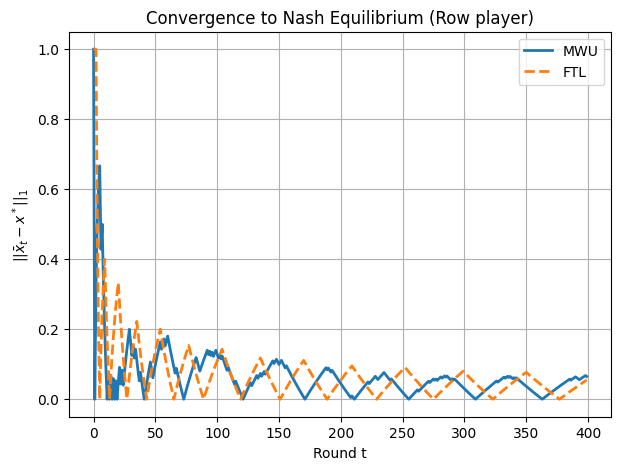

Avg tail distances: 0.036182770417388134 0.03695305332900753


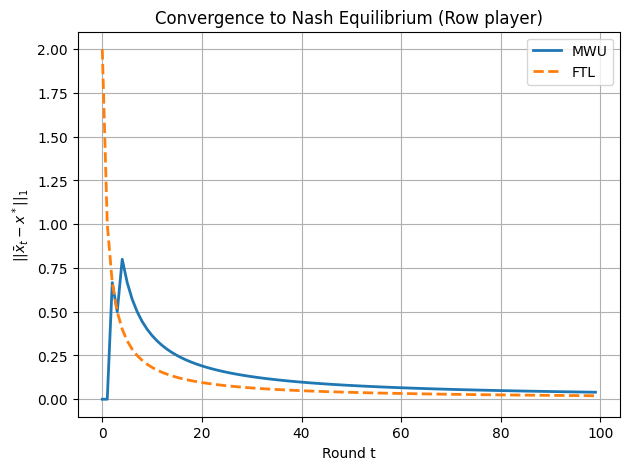

Avg tail distances: 0.10374755035279241 0.13582843403891812


In [9]:
# === Public tests: Task 4 ===
def _ok4(name, fn):
    try:
        fn(); print(f"✅ {name} — passed")
    except AssertionError as e:
        print(f"❌ {name} — {e}")

def test_avg_over_time_tiny():
    avg = average_strategy_over_time_row([0,2,2,1,2], 3)
    expected = np.array([
        [1,0,0],
        [0.5,0,0.5],
        [1/3,0,2/3],
        [0.25,0.25,0.5],
        [0.2,0.2,0.6],
    ])
    assert np.allclose(avg, expected)

def test_distance_basic():
    avg = np.array([[1,0],[0.6,0.4],[0.5,0.5]], float)
    x_star = np.array([0.5,0.5], float)
    d = distance_to_NE(avg, x_star, ord='l1')
    assert d.shape==(3,)
    assert np.isclose(d[-1], 0.0)

_ok4("T4: avg over time tiny", test_avg_over_time_tiny)
_ok4("T4: distance basic", test_distance_basic)

def test_matching_pennies_convergence():
    # Row payoff matrix (col gets the negative)
    A = np.array([[+1, -1],
                  [-1, +1]], float)
    B = -A
    x_star = np.array([0.5, 0.5])
    T = 400

    out = compare_selfplay_convergence(A, B, T, x_star,
                                       eta_row=0.1, eta_col=0.1,
                                       seed=631)
    d_ftl, d_mwu = out["d_ftl"], out["d_mwu"]

    # Sanity: correct shapes
    assert d_ftl.shape == (T,)
    assert d_mwu.shape == (T,)

    # FTL tends to cycle away from NE; MWU should average closer in tail
    tail_ftl = np.mean(d_ftl[-100:])
    tail_mwu = np.mean(d_mwu[-100:])
    print("Avg tail distances:", tail_ftl, tail_mwu)

    assert tail_mwu < tail_ftl + 0.2, "MWU should not be worse than FTL in MP"
    assert tail_mwu < 0.5, "MWU should be reasonably close to NE on average"

test_matching_pennies_convergence()

def test_cooperative_convergence():
    # both players get reward for a_1, a greater reward when both choose a_1
    A = np.array([[0, 0],
                  [0.5, 1]], float)
    B = np.array([[0, 0.5],
                  [0, 1]], float)
    x_star = np.array([0, 1])
    T = 100

    out = compare_selfplay_convergence(A, B, T, x_star,
                                       eta_row=0.2, eta_col=0.2,
                                       seed=42)
    d_ftl, d_mwu = out["d_ftl"], out["d_mwu"]

    # Sanity: correct shapes
    assert d_ftl.shape == (T,)
    assert d_mwu.shape == (T,)

    # FTL tends to cycle away from NE; MWU should average closer in tail
    tail_ftl = np.mean(d_ftl[-100:])
    tail_mwu = np.mean(d_mwu[-100:])
    print("Avg tail distances:", tail_ftl, tail_mwu)

    assert tail_mwu > tail_ftl, "MWU should not be better than FTL in this cooperative game"

test_cooperative_convergence()


✏️ Methods Note (Reflection)

Please add a short note (5–10 sentences) reflecting on your work for this assignment. You might address questions such as:

- Which parts of the code did you find most challenging to implement, and why?

- How did you verify that your implementations were correct? (e.g., reasoning, manual checks, extra experiments)

- Did you notice any interesting behavior of the algorithms when you tested them?

- If you had more time, how might you improve or extend your code?

- What did you learn about regret minimization or equilibria through coding these tasks?

This note will not be graded for correctness, but for thoughtful engagement.

Task 1 was very easy and straightforward, I changed a few of the test cases to make sure it was running as intended. In task 2 I decided to reimplement ftl_row rather than calling it in self-play so I could keep the row and col players in the same iteration, this required masking the most recent row action from the column player's average strategy prediction. For this task I wrote a couple new tests to watch each player's action choices under a larger T. First in a cooperative game I saw that when each player defaults to a_0 and they score, neither want to switch actions because they predict the other player will continue a_0 and they can both continue scoring. When the players have 0sum reward matricies (A scores on same actions, B scores on different actions), we observe each player switching their action only once their opponent's scoring action reaches >50% usage (at 50-50% an agent will choose their first action a_0). In task 3 I implemented MWU by modifying the weights in each iteration, and in self-play I kept track of each player's weights separately and let those weights influence how the player randomly selects their action each round. For testing I printed player actions and their P matrix after each game to observe how eachother's actions effect their weights, importantly that when their opponent chooses and action they predict that same action occuring again at a higher weight than previously, and balancing their weights when their opponent switches actions. In a cooperative game (test_mwu_self_play_shapes) we see both players trend towards a_0 but still randomply choosing a_1, row_player with their higher eta was much more rapid to trend to a_0 and reactive to col_players early a_1 picks. In an adversary game (again with row_player at a higher eta) we see both players trying to switch actions to score on eachother but row_player is much faster to switch and begin scoring while col_player will often continue an action for longer. In the last test where their eta's are balanced, we see both players oscillating actions similarly to attempt to score on one another. In task 4 we see in matching pennies that the optimal action distribution is [.5, .5] and both strategies converge to this, FTL rapidly going in and out of optimal decisions while MWU is a little slower but crosses equally weighted actions as their average strategy over time many times as well. When making the game cooperative I decided to let either agent gain when they choose a_1, but the largest reward is given when they both select a_1. It makes sense that FTL has much more rapid convergance in this game, the players observe eachother and act to score, benefitting from keeping consistent actions. MWU converges as the weights reflect what FTL finds, but this takes longer to unbalance the weight distributions and allow each player to randomly select a_1 consitently.\
I was happy to get hands-on experience working on these algorithms and being able to observe how they influence action selection. FTL while simple can be a strong action selector under circumstances that benefit it, MWU while different to  neurons use similar practices to use observations to balance its held knowledge.